# Flood Risk Scoring — Stage 1: Setup, Data Loading & EDA
**Project:** Flood risk scoring framework for insurance underwriting  
**Dataset:** Kaggle Playground Series S4E5  
**Target:** `FloodProbability` (continuous, 0–1)  

## 0. Install dependencies
Run once, then restart kernel.

In [1]:
# !pip install pandas numpy scikit-learn xgboost shap optuna matplotlib seaborn

## 1. Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})
TEAL = '#1D9E75'
BLUE = '#378ADD'
CORAL = '#D85A30'

print('Imports OK')

Imports OK


## 2. Load data
Place `train.csv` and `test.csv` in a `data/` folder next to this notebook.  
Download from: https://www.kaggle.com/competitions/playground-series-s4e5/data

In [3]:
train = pd.read_csv("train.csv.csv")
test  = pd.read_csv("test.csv.csv")

print(f'Train shape : {train.shape}')
print(f'Test shape  : {test.shape}')
train.head(3)

Train shape : (1117957, 22)
Test shape  : (745305, 21)


,id,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
0,0,5,8,5,8,6,4,4,3,3,...,5,3,3,5,4,7,5,7,3,0.445
1,1,6,7,4,4,8,8,3,5,4,...,7,2,0,3,5,3,3,4,3,0.450
2,2,6,5,6,7,3,7,1,5,4,...,7,3,7,5,6,8,2,3,3,0.530


## 3. Sanity checks

In [ ]:
# --- Data types ---
print('=== dtypes ===')
print(train.dtypes)
print()

# --- Missing values ---
print('=== Missing values (train) ===')
print(train.isnull().sum())
print()

# --- Basic stats ---
print('=== Descriptive stats ===')
train.describe().round(2)

=== dtypes ===
id                                   int64
MonsoonIntensity                     int64
TopographyDrainage                   int64
RiverManagement                      int64
Deforestation                        int64
Urbanization                         int64
ClimateChange                        int64
DamsQuality                          int64
Siltation                            int64
AgriculturalPractices                int64
Encroachments                        int64
IneffectiveDisasterPreparedness      int64
DrainageSystems                      int64
CoastalVulnerability                 int64
Landslides                           int64
Watersheds                           int64
DeterioratingInfrastructure          int64
PopulationScore                      int64
WetlandLoss                          int64
InadequatePlanning                   int64
PoliticalFactors                     int64
FloodProbability                   float64
dtype: object

=== Missing values (trai

,id,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
count,1117957.00,1117957.00,1117957.00,1117957.00,1117957.00,1117957.00,1117957.00,1117957.00,1117957.00,1117957.00,...,1117957.00,1117957.00,1117957.00,1117957.00,1117957.00,1117957.00,1117957.00,1117957.00,1117957.00,1117957.00
mean,558978.00,4.92,4.93,4.96,4.94,4.94,4.93,4.96,4.93,4.94,...,4.95,4.95,4.93,4.93,4.93,4.93,4.95,4.94,4.94,0.50
std,322726.53,2.06,2.09,2.07,2.05,2.08,2.06,2.08,2.07,2.07,...,2.07,2.09,2.08,2.08,2.06,2.07,2.07,2.08,2.09,0.05
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.28
25%,279489.00,3.00,3.00,4.00,4.00,3.00,3.00,4.00,3.00,3.00,...,4.00,3.00,3.00,3.00,3.00,3.00,4.00,3.00,3.00,0.47
50%,558978.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,...,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,0.50
75%,838467.00,6.00,6.00,6.00,6.00,6.00,6.00,6.00,6.00,6.00,...,6.00,6.00,6.00,6.00,6.00,6.00,6.00,6.00,6.00,0.54
max,1117956.00,16.00,18.00,16.00,17.00,17.00,17.00,16.00,16.00,16.00,...,17.00,17.00,16.00,16.00,17.00,18.00,19.00,16.00,16.00,0.72


In [5]:
# Define feature groups — used throughout the project
TARGET = 'FloodProbability'

NATURAL_FEATURES = [
    'MonsoonIntensity', 'TopographyDrainage', 'ClimateChange',
    'CoastalVulnerability', 'Landslides', 'Watersheds'
]
INFRA_FEATURES = [
    'Deforestation', 'Urbanization', 'RiverManagement', 'DamsQuality',
    'DrainageSystems', 'DeterioratingInfrastructure', 'Siltation', 'Encroachments'
]
SOCIO_FEATURES = [
    'PopulationScore', 'AgriculturalPractices', 'WetlandLoss',
    'PoliticalFactors', 'InadequatePlanning', 'IneffectiveDisasterPreparedness'
]
ALL_FEATURES = NATURAL_FEATURES + INFRA_FEATURES + SOCIO_FEATURES

# Drop 'id' column if present
if 'id' in train.columns:
    train = train.drop(columns=['id'])
if 'id' in test.columns:
    test_ids = test['id'].copy()
    test = test.drop(columns=['id'])

print(f'Features  : {len(ALL_FEATURES)}')
print(f'Target    : {TARGET}')
print(f'Train rows: {len(train):,}')

Features  : 20
Target    : FloodProbability
Train rows: 1,117,957


## 4. EDA
### 4a. Target distribution

In [7]:
import os

save_dir = "outputs"
os.makedirs(save_dir, exist_ok=True)

plt.savefig(os.path.join(save_dir, "01_target_distribution.png"), bbox_inches='tight')

<Figure size 768x576 with 0 Axes>

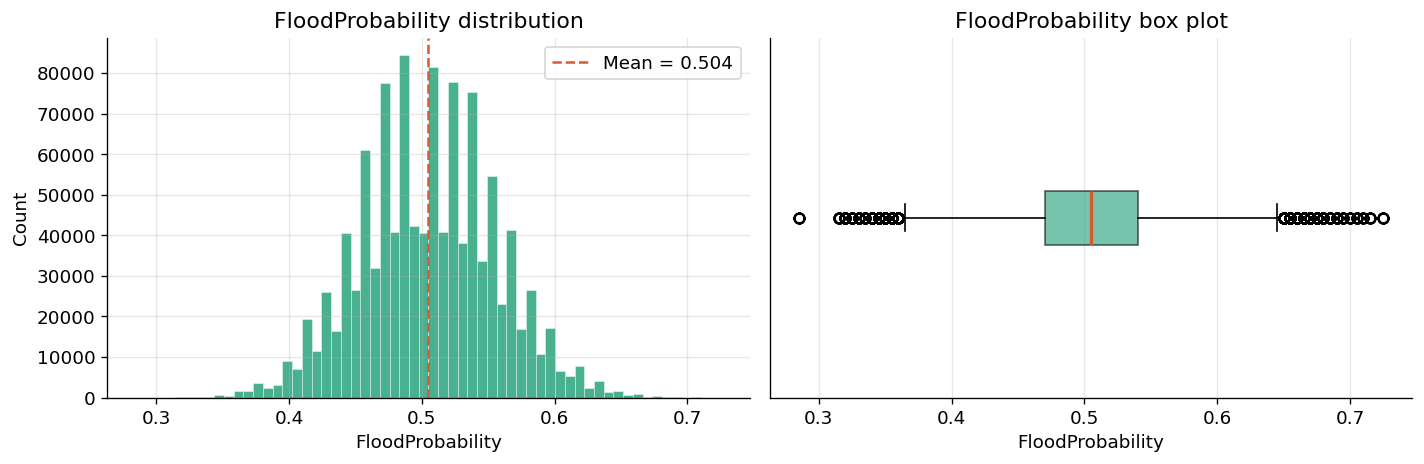

Mean  : 0.5045
Std   : 0.0510
Min   : 0.2850
Max   : 0.7250


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(train[TARGET], bins=60, color=TEAL, alpha=0.8, edgecolor='white', linewidth=0.3)
axes[0].set_title('FloodProbability distribution')
axes[0].set_xlabel('FloodProbability')
axes[0].set_ylabel('Count')
axes[0].axvline(train[TARGET].mean(), color=CORAL, linestyle='--', linewidth=1.5, label=f'Mean = {train[TARGET].mean():.3f}')
axes[0].legend()

# Box plot
axes[1].boxplot(train[TARGET], vert=False, patch_artist=True,
                boxprops=dict(facecolor=TEAL, alpha=0.6),
                medianprops=dict(color=CORAL, linewidth=2))
axes[1].set_title('FloodProbability box plot')
axes[1].set_xlabel('FloodProbability')
axes[1].set_yticks([])

plt.tight_layout()
plt.savefig('outputs/01_target_distribution.png', bbox_inches='tight')
plt.show()

print(f"Mean  : {train[TARGET].mean():.4f}")
print(f"Std   : {train[TARGET].std():.4f}")
print(f"Min   : {train[TARGET].min():.4f}")
print(f"Max   : {train[TARGET].max():.4f}")

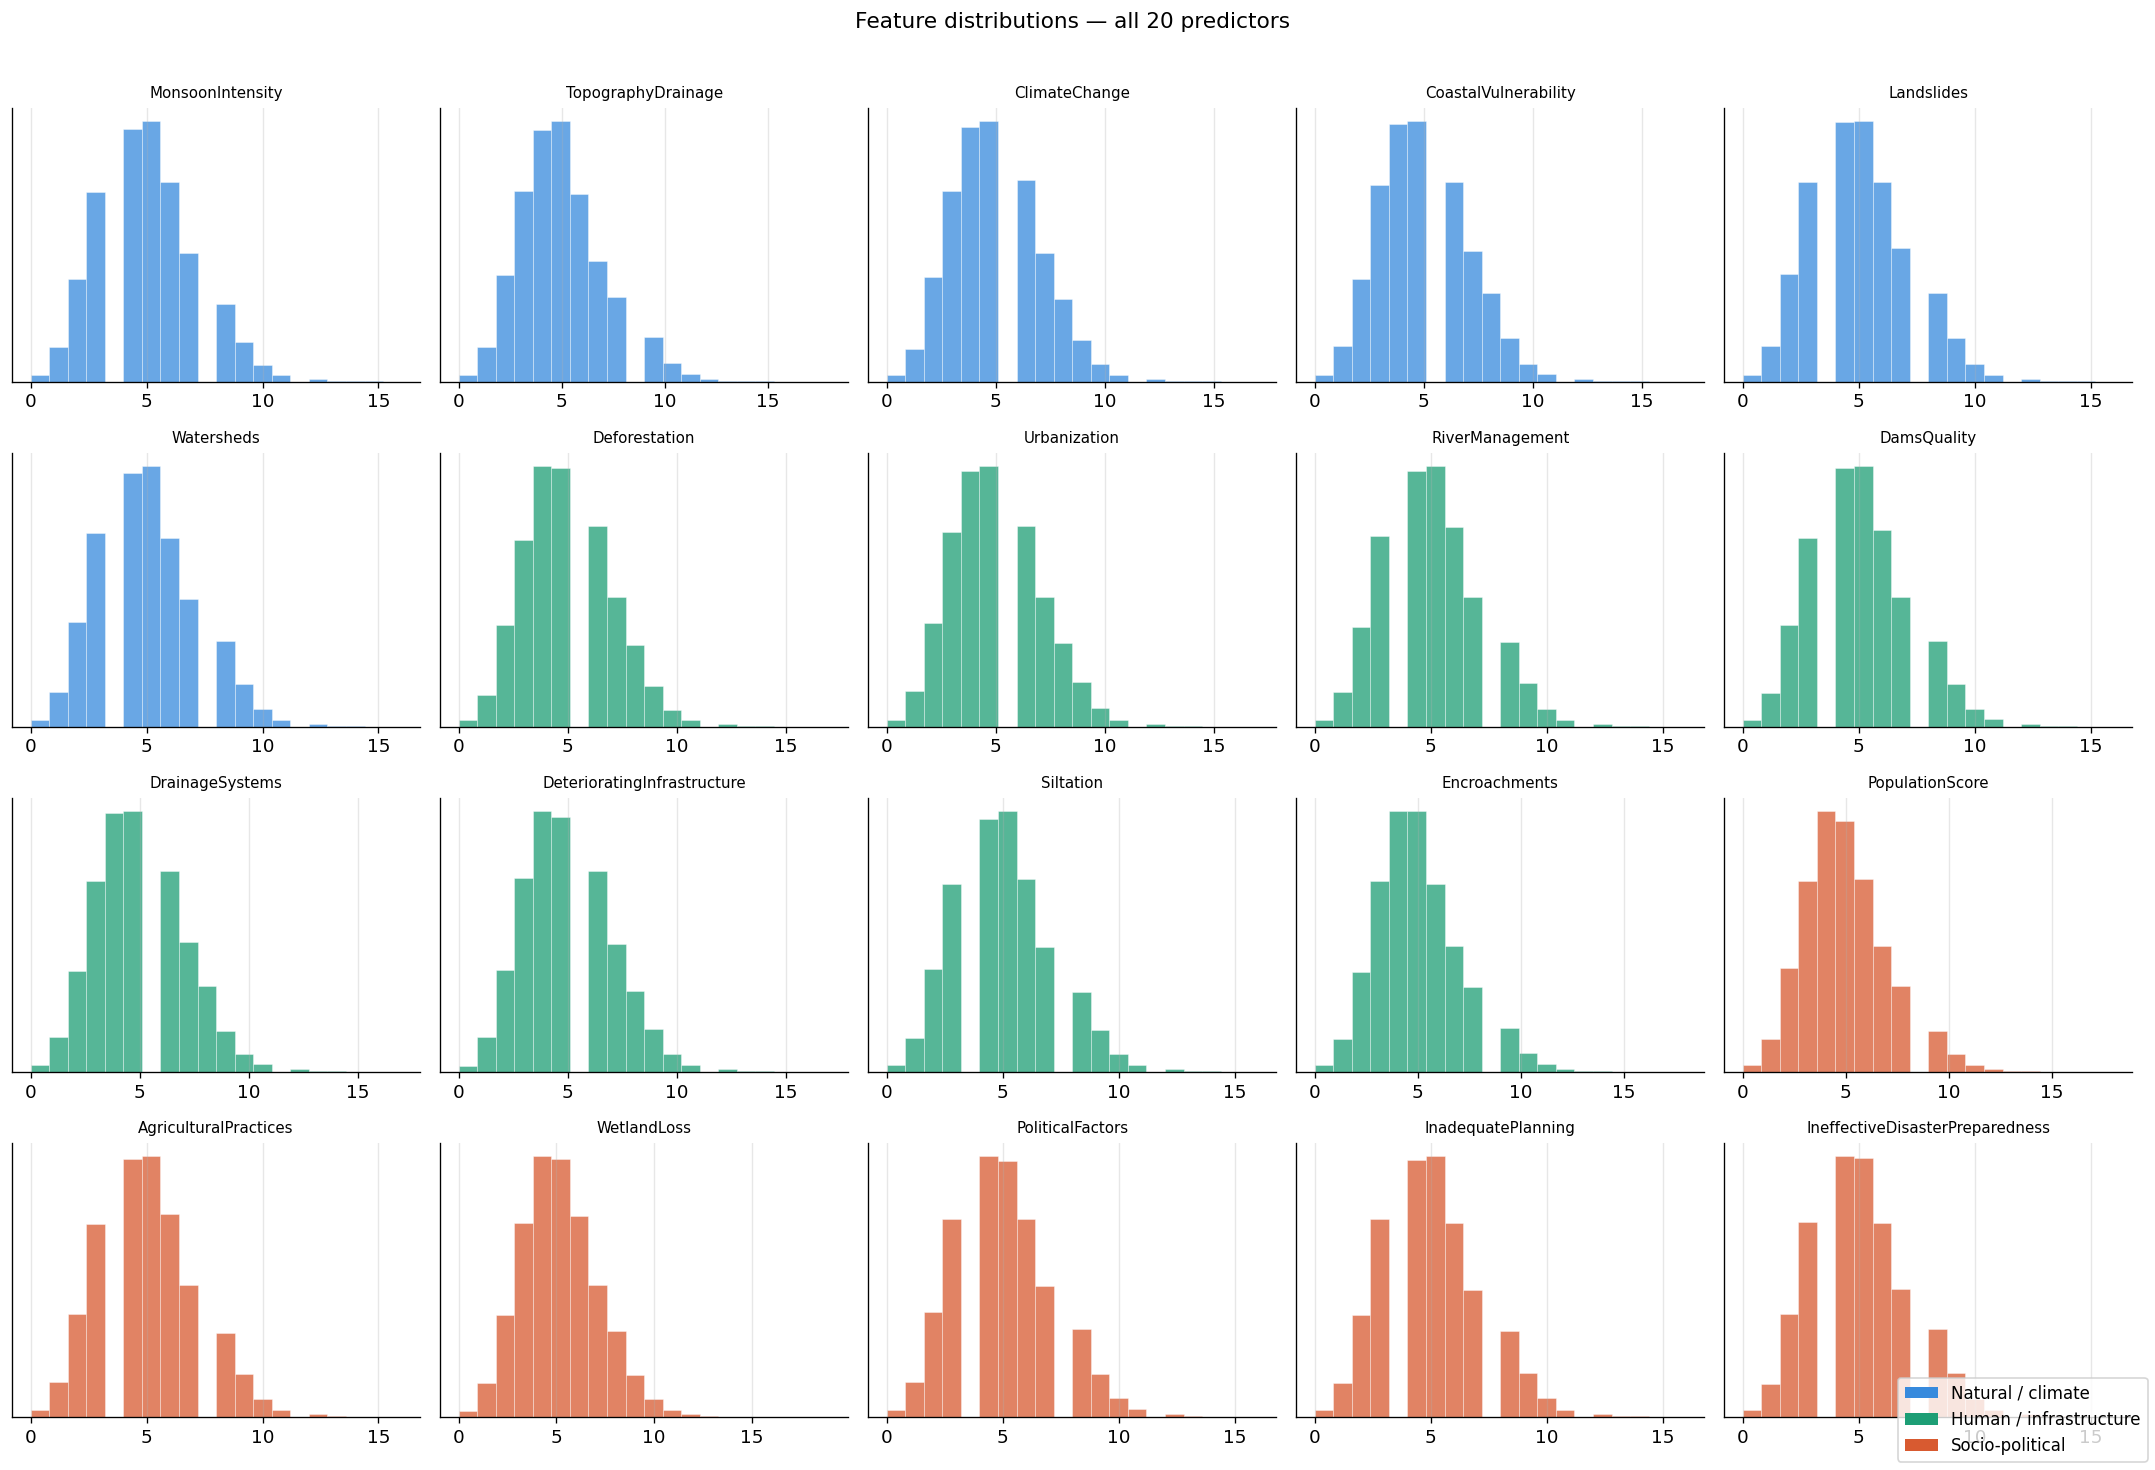

Observation: features share a similar ordinal 1–20 scale — no normalisation required for tree models.


In [9]:
fig, axes = plt.subplots(4, 5, figsize=(18, 12))
axes = axes.flatten()

colors = ([BLUE] * len(NATURAL_FEATURES) +
          [TEAL] * len(INFRA_FEATURES) +
          [CORAL] * len(SOCIO_FEATURES))

for i, (feat, col) in enumerate(zip(ALL_FEATURES, colors)):
    axes[i].hist(train[feat], bins=20, color=col, alpha=0.75, edgecolor='white', linewidth=0.3)
    axes[i].set_title(feat, fontsize=9)
    axes[i].set_yticks([])

# Hide unused subplot
for j in range(len(ALL_FEATURES), len(axes)):
    axes[j].set_visible(False)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=BLUE,  label='Natural / climate'),
    Patch(facecolor=TEAL,  label='Human / infrastructure'),
    Patch(facecolor=CORAL, label='Socio-political')
]
fig.legend(handles=legend_elements, loc='lower right', fontsize=10)
fig.suptitle('Feature distributions — all 20 predictors', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('outputs/02_feature_distributions.png', bbox_inches='tight')
plt.show()

print('Observation: features share a similar ordinal 1–20 scale — no normalisation required for tree models.')

### 4b. Feature distributions

### 4c. Correlation heatmap

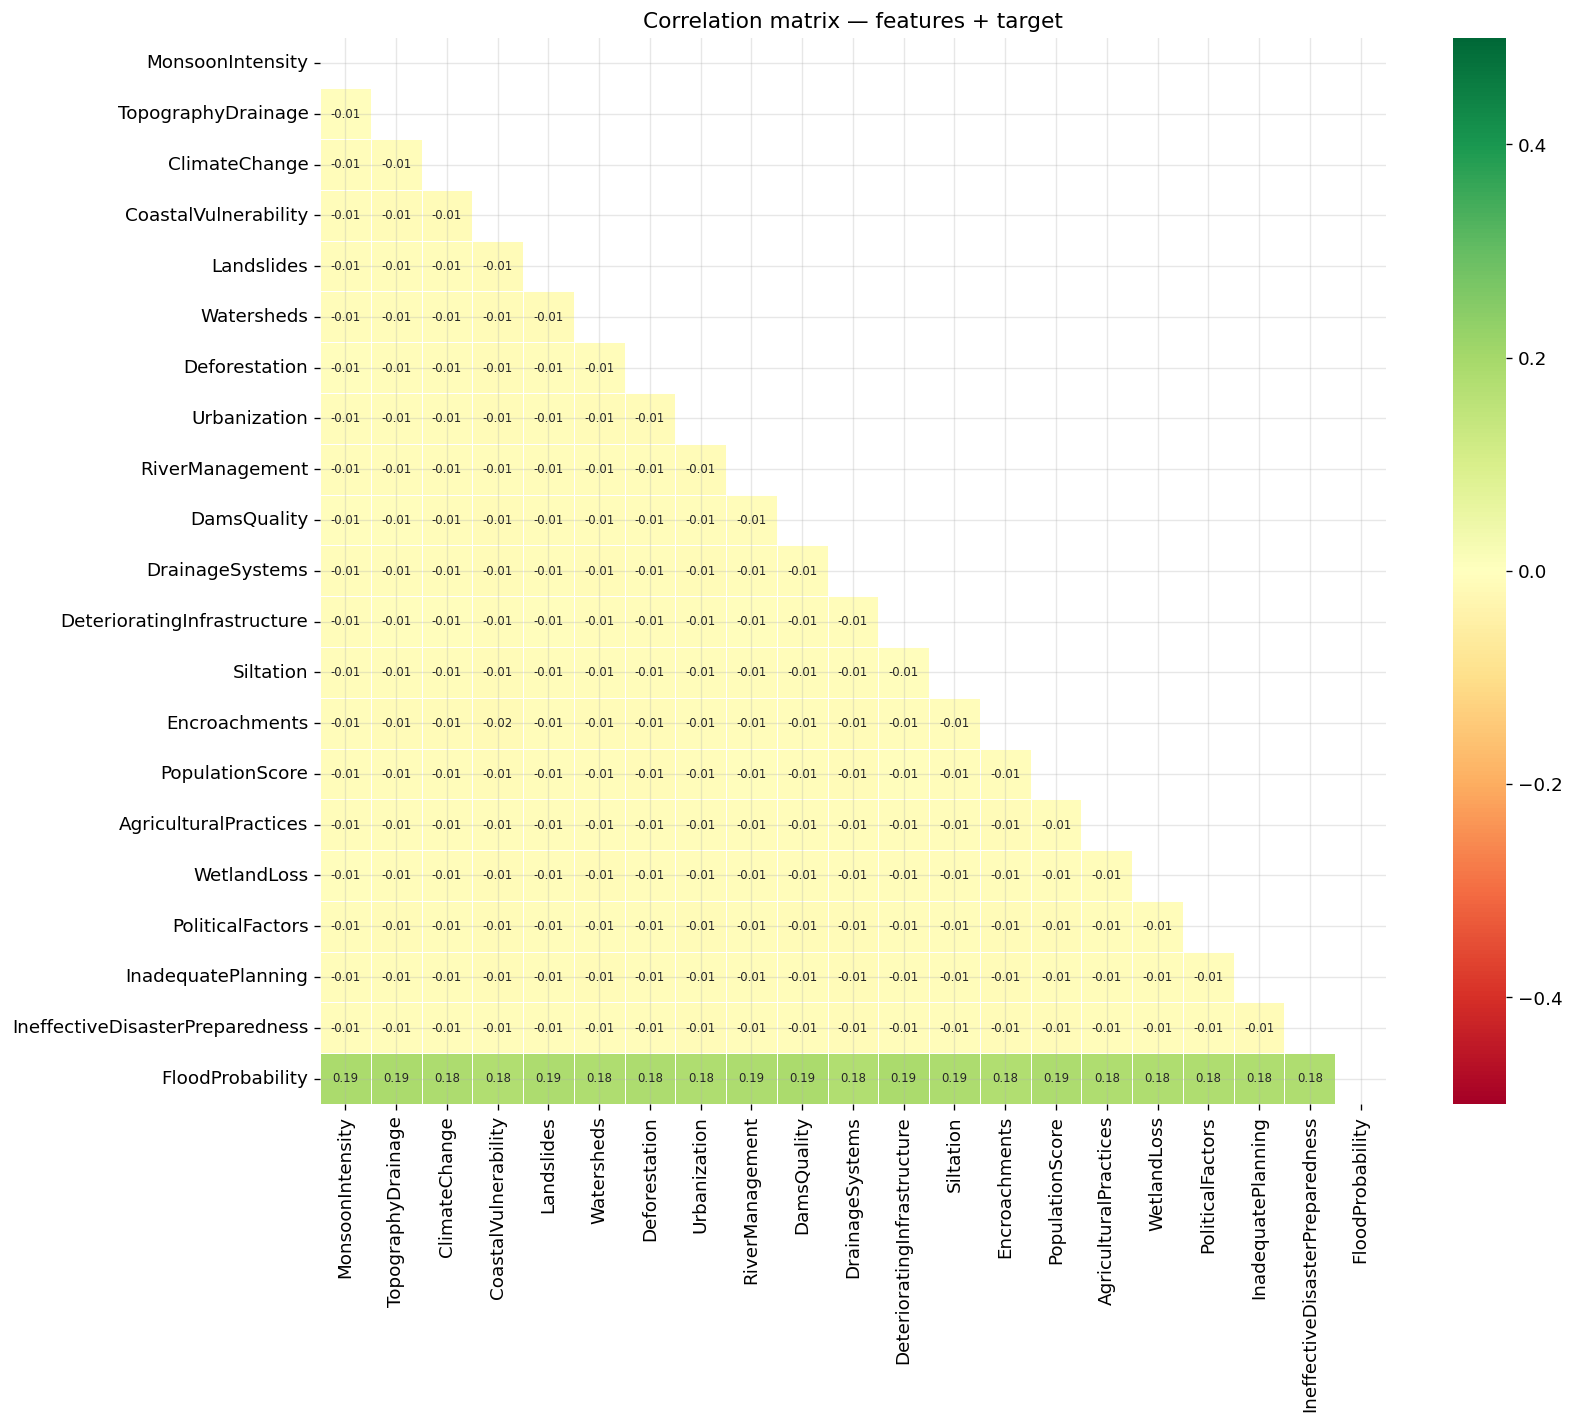

Top 5 individual feature correlations with target:
DeterioratingInfrastructure    0.190007
MonsoonIntensity               0.189098
DamsQuality                    0.187996
TopographyDrainage             0.187635
RiverManagement                0.187131
Name: FloodProbability, dtype: float64

Observation: near-zero pairwise feature correlations mean the problem is not simply additive.
This motivates ensemble methods over plain linear regression.


In [10]:
corr = train[ALL_FEATURES + [TARGET]].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))  # show lower triangle only
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, vmin=-0.5, vmax=0.5,
    linewidths=0.4, ax=ax, annot_kws={'size': 7}
)
ax.set_title('Correlation matrix — features + target', fontsize=13)
plt.tight_layout()
plt.savefig('outputs/03_correlation_heatmap.png', bbox_inches='tight')
plt.show()

# Key EDA finding
feat_corrs = corr[TARGET][ALL_FEATURES].abs().sort_values(ascending=False)
print('Top 5 individual feature correlations with target:')
print(feat_corrs.head())
print()
print('Observation: near-zero pairwise feature correlations mean the problem is not simply additive.')
print('This motivates ensemble methods over plain linear regression.')

### 4d. Top feature vs target scatter

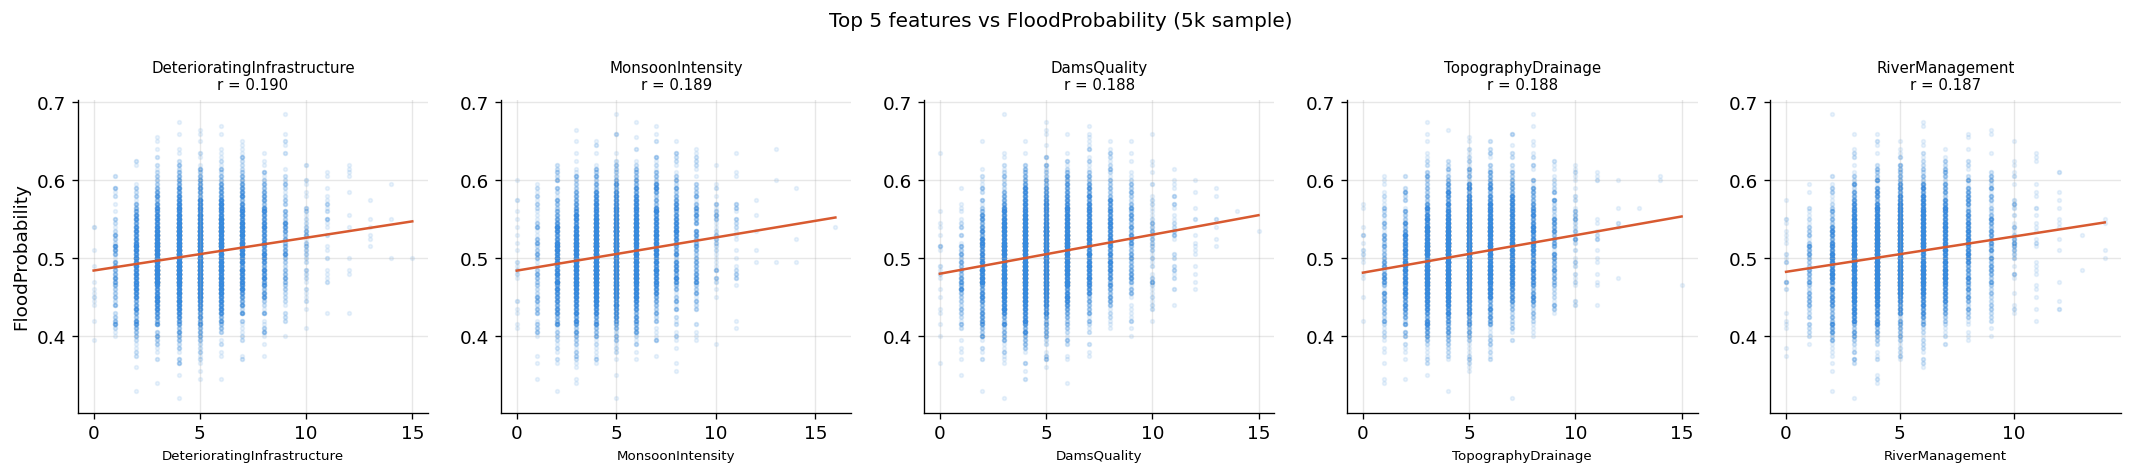

Observation: even top-correlated features show weak individual relationships — ensemble methods needed.


In [11]:
top5 = feat_corrs.head(5).index.tolist()

# Sample 5k rows for speed
sample = train.sample(5000, random_state=42)

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for i, feat in enumerate(top5):
    axes[i].scatter(sample[feat], sample[TARGET], alpha=0.1, s=5, color=BLUE)
    # Add trend line
    m, b = np.polyfit(sample[feat], sample[TARGET], 1)
    x_line = np.linspace(sample[feat].min(), sample[feat].max(), 100)
    axes[i].plot(x_line, m * x_line + b, color=CORAL, linewidth=1.5)
    r = train[[feat, TARGET]].corr().iloc[0, 1]
    axes[i].set_title(f'{feat}\nr = {r:.3f}', fontsize=9)
    axes[i].set_xlabel(feat, fontsize=8)
    axes[i].set_ylabel('FloodProbability' if i == 0 else '')

fig.suptitle('Top 5 features vs FloodProbability (5k sample)', fontsize=12)
plt.tight_layout()
plt.savefig('outputs/04_feature_vs_target.png', bbox_inches='tight')
plt.show()

print('Observation: even top-correlated features show weak individual relationships — ensemble methods needed.')

## 5. Feature engineering
Three domain composite scores + two interaction terms + one total score.

In [12]:
def engineer_features(df):
    df = df.copy()

    # --- Domain composite scores (motivated by flood science literature) ---
    df['NaturalRisk']  = df[NATURAL_FEATURES].mean(axis=1)
    df['InfraRisk']    = df[INFRA_FEATURES].mean(axis=1)
    df['SocioRisk']    = df[SOCIO_FEATURES].mean(axis=1)

    # --- Interaction terms (scientifically motivated) ---
    # Urban flash flood: heavy rain × impermeable surfaces
    df['Monsoon_x_Urbanization']     = df['MonsoonIntensity'] * df['Urbanization']
    # Land degradation compound risk: soil erosion + slope instability
    df['Deforestation_x_Landslides'] = df['Deforestation']    * df['Landslides']

    # --- Total risk score (simple additive baseline feature) ---
    df['TotalRiskScore'] = df[ALL_FEATURES].sum(axis=1)

    return df

train_eng = engineer_features(train)
test_eng  = engineer_features(test)

ENGINEERED = ['NaturalRisk', 'InfraRisk', 'SocioRisk',
              'Monsoon_x_Urbanization', 'Deforestation_x_Landslides',
              'TotalRiskScore']
FULL_FEATURES = ALL_FEATURES + ENGINEERED

print(f'Original features : {len(ALL_FEATURES)}')
print(f'Engineered added  : {len(ENGINEERED)}')
print(f'Total features    : {len(FULL_FEATURES)}')
train_eng[ENGINEERED].describe().round(2)

Original features : 20
Engineered added  : 6
Total features    : 26


,NaturalRisk,InfraRisk,SocioRisk,Monsoon_x_Urbanization,Deforestation_x_Landslides,TotalRiskScore
count,1117957.00,1117957.00,1117957.00,1117957.00,1117957.00,1117957.00
mean,4.93,4.94,4.94,24.28,24.33,98.79
std,0.83,0.71,0.82,14.96,14.91,8.31
min,1.33,1.62,1.50,0.00,0.00,63.00
25%,4.33,4.50,4.33,14.00,14.00,94.00
50%,4.83,4.88,5.00,21.00,21.00,98.00
75%,5.50,5.38,5.50,32.00,32.00,104.00
max,10.00,9.00,9.83,168.00,182.00,144.00


Engineered feature correlations with target:
TotalRiskScore                0.9192
InfraRisk                     0.5414
NaturalRisk                   0.4640
SocioRisk                     0.4615
Monsoon_x_Urbanization        0.2541
Deforestation_x_Landslides    0.2537
Name: FloodProbability, dtype: float64


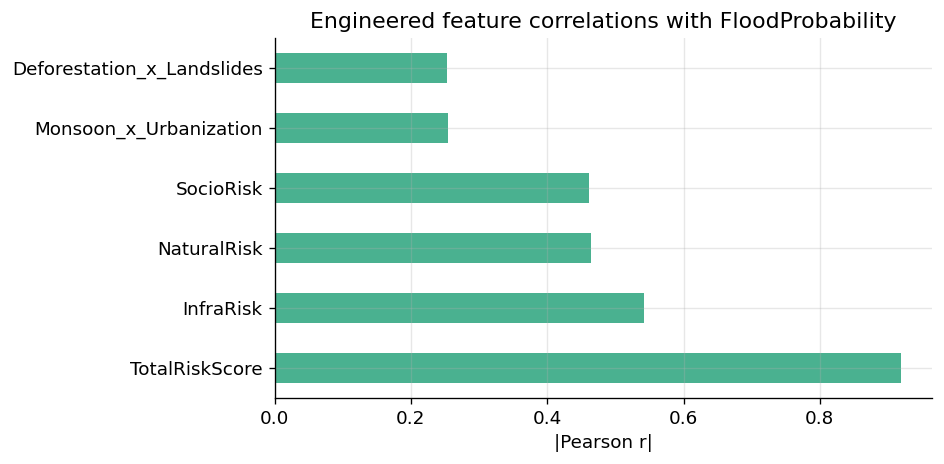

In [13]:
# Check engineered feature correlations with target
eng_corrs = train_eng[ENGINEERED + [TARGET]].corr()[TARGET][ENGINEERED].abs().sort_values(ascending=False)
print('Engineered feature correlations with target:')
print(eng_corrs.round(4))

fig, ax = plt.subplots(figsize=(8, 4))
eng_corrs.plot(kind='barh', ax=ax, color=TEAL, alpha=0.8)
ax.set_title('Engineered feature correlations with FloodProbability')
ax.set_xlabel('|Pearson r|')
plt.tight_layout()
plt.savefig('outputs/05_engineered_feature_corrs.png', bbox_inches='tight')
plt.show()

## 6. Save processed data

In [15]:
import os
os.makedirs('outputs', exist_ok=True)
os.makedirs('models', exist_ok=True)
os.makedirs('data', exist_ok=True)

train_eng.to_csv('data/train_engineered.csv', index=False)
test_eng.to_csv('data/test_engineered.csv', index=False)

# Save feature list for use in next notebooks
import json
with open('data/feature_config.json', 'w') as f:
    json.dump({
        'all_features': ALL_FEATURES,
        'natural': NATURAL_FEATURES,
        'infra': INFRA_FEATURES,
        'socio': SOCIO_FEATURES,
        'engineered': ENGINEERED,
        'full_features': FULL_FEATURES,
        'target': TARGET
    }, f, indent=2)

print('Saved:')
print('  data/train_engineered.csv')
print('  data/test_engineered.csv')
print('  data/feature_config.json')
print()
print('Ready for notebook 02 — model training.')

Saved:
  data/train_engineered.csv
  data/test_engineered.csv
  data/feature_config.json

Ready for notebook 02 — model training.


---
## EDA Summary

| Finding | Implication |
|---|---|
| Target is near-normally distributed around 0.5 | RMSE is a fair metric; no need to transform target |
| All features on similar 1–20 ordinal scale | No normalisation required for tree models; scale for MLP |
| Near-zero pairwise feature correlations | Problem is not simply additive — tree ensembles expected to outperform linear models |
| Weak individual feature-target correlations | Feature interactions matter — SHAP over correlation analysis for driver identification |
| TotalRiskScore shows strong correlation with target | Simple additive score captures signal; adding interaction terms should improve further |